In [1]:
# 0

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from itertools import combinations

In [2]:
# 1

XLSX = 'kospi_data.xlsx'
FIN_OUT = 'financials.parquet'

SHEET_ITEM = {
    '01_actq': 'actq', '02_rectq': 'rectq', '03_invtq': 'invtq',
    '04_ppentq': 'ppentq', '05_atq': 'atq', '06_lctq': 'lctq',
    '07_dlttq': 'dlttq', '08_dlcq': 'dlcq', '09_ltq': 'ltq',
    '10_seqq': 'seqq', '11_cogsq': 'cogsq', '12_xsgaq': 'xsgaq',
    '13_saleq': 'saleq', '14_apq': 'apq', '15_opinc': 'opinc',
    '16_xintq': 'xintq', '17_ibq': 'ibq', '18_txditcq': 'txditcq',
    '19_pstkq': 'pstkq', '20_cheq': 'cheq', '21_oancfq': 'oancfq',
    '22_dpq': 'dpq', '23_dvq': 'dvq', '24_cstkq': 'cstkq',
    '25_req': 'req', '26_epsq': 'epsq',
}

def load_sheet(path, sheet, var):
    raw = pd.read_excel(path, sheet_name=sheet, header=None)
    periods = raw.iloc[9, 3:].tolist()
    body = raw.iloc[13:, :].reset_index(drop=True)
    codes = body.iloc[:, 0].astype(str)
    mask = codes.str.startswith('A')
    codes = codes[mask].reset_index(drop=True)
    vals = body.loc[mask.values, 3:].apply(pd.to_numeric, errors='coerce').reset_index(drop=True)
    vals.columns = periods
    vals.insert(0, 'code', codes)
    long = vals.melt(id_vars='code', var_name='period', value_name=var)
    long['date'] = pd.to_datetime(long['period'].astype(int).astype(str), format='%Y%m') + pd.offsets.MonthEnd(0)
    return long[['code', 'date', var]]

def build_financials(path=XLSX, out=FIN_OUT):
    if Path(out).exists():
        fin = pd.read_parquet(out)
        print(f'{out} loaded. shape {fin.shape}  n_comp {fin["code"].nunique()}')
        return fin
    fin = None
    for sheet, var in SHEET_ITEM.items():
        long = load_sheet(path, sheet, var)
        fin = long if fin is None else fin.merge(long, on=['code', 'date'], how='outer')
    fin = fin.sort_values(['code', 'date']).reset_index(drop=True)
    fin.to_parquet(out)
    print(f'{out} written. shape {fin.shape}  n_comp {fin["code"].nunique()}  n_date {fin["date"].nunique()}')
    return fin

financials = build_financials()
print('columns:', financials.columns.tolist())
print('n_comp 기대 1118, n_date 기대 105')

financials.parquet loaded. shape (117390, 28)  n_comp 1118
columns: ['code', 'date', 'actq', 'rectq', 'invtq', 'ppentq', 'atq', 'lctq', 'dlttq', 'dlcq', 'ltq', 'seqq', 'cogsq', 'xsgaq', 'saleq', 'apq', 'opinc', 'xintq', 'ibq', 'txditcq', 'pstkq', 'cheq', 'oancfq', 'dpq', 'dvq', 'cstkq', 'req', 'epsq']
n_comp 기대 1118, n_date 기대 105


In [3]:
# 2

FVOL_COLS = ['actq', 'rectq', 'invtq', 'ppentq', 'atq', 'lctq', 'dlcq',
             'apq', 'dlttq', 'ltq', 'seqq', 'xoprq', 'cogsq', 'xsgaq']

def compute_fvol(df, deflator='saleq', fvol_cols=FVOL_COLS, diff_lag=4, win=8, min_obs=4):
    d = df.sort_values(['code', 'date']).reset_index(drop=True).copy()
    d['xoprq'] = d['cogsq'] + d['xsgaq']

    pq = pd.PeriodIndex(d['date'], freq='Q')
    d['qidx'] = pq.year * 4 + (pq.quarter - 1)

    g = d.groupby('code', sort=False)
    has_lag = (d['qidx'] - g['qidx'].shift(diff_lag)) == diff_lag
    for c in fvol_cols:
        d[f'd_{c}'] = np.where(has_lag, d[c] - g[c].shift(diff_lag), np.nan)

    g = d.groupby('code', sort=False)
    for c in fvol_cols:
        d[f'std_{c}'] = (g[f'd_{c}'].apply(lambda s: s.rolling(win, min_periods=min_obs).std())
                         .reset_index(level=0, drop=True))

    d['defl_pos'] = d[deflator].where(d[deflator] > 0)
    g = d.groupby('code', sort=False)
    d['avg_defl'] = (g['defl_pos'].apply(lambda s: s.rolling(win, min_periods=min_obs).mean())
                     .reset_index(level=0, drop=True))
    d['avg_defl'] = d['avg_defl'].where(d['avg_defl'] > 0)

    ind = []
    for c in fvol_cols:
        d[f'fvol_{c}'] = d[f'std_{c}'] / d['avg_defl']
        ind.append(f'fvol_{c}')
    return d, ind

def finalize_fvol(d, ind, fvol_cols=FVOL_COLS, min_valid=10, suffix=''):
    d = d.copy()
    rcols = [f'rank_{c}' for c in fvol_cols]
    ranked = d.groupby('date')[ind].rank(pct=True)
    ranked.columns = rcols
    d = pd.concat([d, ranked], axis=1)
    d['n_valid'] = d[rcols].notna().sum(axis=1)
    col = f'FVOL{suffix}'
    d[col] = d[rcols].mean(axis=1)
    d.loc[d['n_valid'] < min_valid, col] = np.nan
    return d, col

financials = pd.read_parquet('financials.parquet')

fv_sale, ind = compute_fvol(financials, deflator='saleq')
fv_sale, col_s = finalize_fvol(fv_sale, ind, suffix='_sale')

fv_asset, ind = compute_fvol(financials, deflator='atq')
fv_asset, col_a = finalize_fvol(fv_asset, ind, suffix='_asset')

fvol = fv_sale[['code', 'date', col_s]].merge(
    fv_asset[['code', 'date', col_a]], on=['code', 'date'])

for c in [col_s, col_a]:
    v = fvol[fvol[c].notna()]
    print(f'{c}: valid {len(v)}  avg firms/q {v.groupby("date").size().mean():.0f}  '
          f'range {v["date"].min().date()}~{v["date"].max().date()}')
    print(f'  describe: {v[c].describe()[["mean","std","min","50%","max"]].round(3).to_dict()}')

corr = fvol[[col_s, col_a]].corr().iloc[0, 1]
print(f'\n매출분모 FVOL vs 자산분모 FVOL 상관: {corr:.3f}')
print('\n분기당 종목수 (매출분모):')
gq = fvol[fvol[col_s].notna()].groupby('date').size()
print(gq.iloc[[0, len(gq)//4, len(gq)//2, 3*len(gq)//4, -1]].to_string())

FVOL_sale: valid 67631  avg firms/q 690  range 2001-12-31~2026-03-31
  describe: {'mean': 0.501, 'std': 0.203, 'min': 0.021, '50%': 0.482, 'max': 1.0}
FVOL_asset: valid 67694  avg firms/q 691  range 2001-12-31~2026-03-31
  describe: {'mean': 0.501, 'std': 0.189, 'min': 0.022, '50%': 0.49, 'max': 0.999}

매출분모 FVOL vs 자산분모 FVOL 상관: 0.713

분기당 종목수 (매출분모):
date
2001-12-31    564
2007-12-31    647
2014-03-31    684
2020-03-31    739
2026-03-31    773


In [4]:
# 3

financials = pd.read_parquet('financials.parquet')
fv, ind = compute_fvol(financials, deflator='saleq')
fv, col = finalize_fvol(fv, ind, suffix='')

rcols = [f'rank_{c}' for c in FVOL_COLS]
valid = fv[fv['FVOL'].notna()].copy()

print('=== Panel A: 14개 개별 측정치 분포 (fvol_k 원값) ===')
print(f'{"item":8s}{"mean":>10s}{"std":>10s}{"median":>10s}{"N":>8s}')
for c in FVOL_COLS:
    s = fv[f'fvol_{c}'].replace([np.inf,-np.inf], np.nan).dropna()
    print(f'{c:8s}{s.mean():>10.3f}{s.std():>10.3f}{s.median():>10.3f}{len(s):>8d}')

print('\n=== Panel B: 각 측정치 rank와 FVOL의 상관 (공통성분) ===')
print('개별 fvol_k rank가 종합 FVOL과 얼마나 상관되는지:')
for c in FVOL_COLS:
    corr = valid[[f'rank_{c}', 'FVOL']].corr().iloc[0,1]
    print(f'  {c:8s}: {corr:.3f}')

print('\n=== 14개 측정치 rank 간 평균 Spearman 상관 ===')
rank_corr = valid[rcols].corr()
mask = ~np.eye(14, dtype=bool)
print(f'  평균 pairwise 상관: {rank_corr.values[mask].mean():.3f}')
print(f'  최소: {rank_corr.values[mask].min():.3f}  최대: {rank_corr.values[mask].max():.3f}')

print('\n=== 상관행렬 (rank 간) ===')
short = [c.replace('q','') for c in FVOL_COLS]
rc = rank_corr.copy()
rc.index = short; rc.columns = short
print(rc.round(2).to_string())

=== Panel A: 14개 개별 측정치 분포 (fvol_k 원값) ===
item          mean       std    median       N
actq         0.577     1.936     0.250   67670
rectq        0.229     0.725     0.115   67648
invtq        0.140     0.326     0.079   65284
ppentq       0.340     3.188     0.098   67634
atq          0.844     3.962     0.315   67670
lctq         0.648     6.431     0.260   67670
dlcq         0.345     1.336     0.163   67660
apq          0.264     5.858     0.110   67628
dlttq        0.224     0.791     0.089   44808
ltq          0.833    19.648     0.257   67670
seqq         0.709    20.142     0.146   67670
xoprq        0.268     1.656     0.127   67074
cogsq        0.237     1.469     0.118   67512
xsgaq        0.071     0.575     0.020   67074

=== Panel B: 각 측정치 rank와 FVOL의 상관 (공통성분) ===
개별 fvol_k rank가 종합 FVOL과 얼마나 상관되는지:
  actq    : 0.824
  rectq   : 0.708
  invtq   : 0.577
  ppentq  : 0.562
  atq     : 0.853
  lctq    : 0.822
  dlcq    : 0.636
  apq     : 0.709
  dlttq   : 0.490
  ltq   

In [5]:
# 4

financials = pd.read_parquet('financials.parquet')
fv, ind = compute_fvol(financials, deflator='saleq')
fv, col = finalize_fvol(fv, ind, suffix='')

d = fv[['code', 'date', 'FVOL']].dropna().copy()
d['qidx'] = pd.PeriodIndex(d['date'], freq='Q').year * 4 + (pd.PeriodIndex(d['date'], freq='Q').quarter - 1)
d = d.sort_values(['code', 'qidx']).reset_index(drop=True)

print('=== FVOL 자기상관 (lag별) ===')
print('같은 종목의 FVOL(t)와 FVOL(t+k) 상관:')
for lag in [1, 2, 4, 8, 12, 20]:
    g = d.copy()
    g['fut_qidx'] = g['qidx'] + lag
    merged = g.merge(g[['code','qidx','FVOL']].rename(columns={'qidx':'fut_qidx','FVOL':'FVOL_fut'}),
                     on=['code','fut_qidx'], how='inner')
    corr = merged[['FVOL','FVOL_fut']].corr().iloc[0,1]
    print(f'  lag {lag:2d}분기 ({lag/4:.1f}년): 상관 {corr:.3f}  (n={len(merged)})')

print('\n=== 분위 유지율 (transition) ===')
print('이번 분기 decile이 k분기 후에도 같은/인접 decile에 남는 비율:')
d['dec'] = d.groupby('date')['FVOL'].transform(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop'))
for lag in [1, 4, 8]:
    g = d.copy()
    g['fut_qidx'] = g['qidx'] + lag
    m = g.merge(g[['code','qidx','dec']].rename(columns={'qidx':'fut_qidx','dec':'dec_fut'}),
                on=['code','fut_qidx'], how='inner')
    same = (m['dec'] == m['dec_fut']).mean()
    adj = (abs(m['dec'] - m['dec_fut']) <= 1).mean()
    print(f'  lag {lag}분기: 동일 decile {same:.1%}, ±1 이내 {adj:.1%}')

print('\n=== 극단 분위의 지속성 (전이 확률) ===')
print('최저(0)·최고(9) decile이 4분기 후 어디로 가는지:')
g = d.copy(); g['fut_qidx'] = g['qidx'] + 4
m = g.merge(g[['code','qidx','dec']].rename(columns={'qidx':'fut_qidx','dec':'dec_fut'}),
            on=['code','fut_qidx'], how='inner')
for start in [0, 9]:
    sub = m[m['dec'] == start]['dec_fut']
    print(f'  decile {start}: 4분기 후 평균 decile {sub.mean():.2f}, 같은 곳 유지 {(sub==start).mean():.1%}')

=== FVOL 자기상관 (lag별) ===
같은 종목의 FVOL(t)와 FVOL(t+k) 상관:
  lag  1분기 (0.2년): 상관 0.974  (n=66658)
  lag  2분기 (0.5년): 상관 0.934  (n=65688)
  lag  4분기 (1.0년): 상관 0.845  (n=63755)
  lag  8분기 (2.0년): 상관 0.671  (n=59995)
  lag 12분기 (3.0년): 상관 0.553  (n=56330)
  lag 20분기 (5.0년): 상관 0.464  (n=49353)

=== 분위 유지율 (transition) ===
이번 분기 decile이 k분기 후에도 같은/인접 decile에 남는 비율:
  lag 1분기: 동일 decile 64.6%, ±1 이내 95.6%
  lag 4분기: 동일 decile 35.0%, ±1 이내 71.9%
  lag 8분기: 동일 decile 24.0%, ±1 이내 55.5%

=== 극단 분위의 지속성 (전이 확률) ===
최저(0)·최고(9) decile이 4분기 후 어디로 가는지:
  decile 0: 4분기 후 평균 decile 0.80, 같은 곳 유지 59.3%
  decile 9: 4분기 후 평균 decile 8.50, 같은 곳 유지 70.1%


In [6]:
# 5

financials = pd.read_parquet('financials.parquet')
ALL_ITEMS = ['actq','rectq','invtq','ppentq','atq','lctq','dlttq','dlcq','ltq',
             'seqq','cogsq','xsgaq','saleq','apq','opinc','xintq','ibq','txditcq',
             'pstkq','cheq','oancfq','dpq','dvq','cstkq','req','epsq']

print('=== 1. 항목별 결측률 (FVOL 14개 표시) ===')
FVOL14 = ['actq','rectq','invtq','ppentq','atq','lctq','dlcq','apq','dlttq','ltq','seqq','cogsq','xsgaq']
for c in ALL_ITEMS:
    nan = financials[c].isna().mean()
    tag = ' [FVOL]' if c in FVOL14 else ''
    print(f'  {c:9s}: {nan:.1%}{tag}')

print('\n=== 2. 폐지 종목 실태 ===')
last_date = financials.groupby('code')['atq'].apply(lambda s: financials.loc[s.index, 'date'][s.notna()].max())
last_date = financials[financials['atq'].notna()].groupby('code')['date'].max()
cutoff = financials['date'].max()
print(f'데이터 최종 시점: {cutoff.date()}')
delisted = last_date[last_date < cutoff - pd.Timedelta(days=200)]
print(f'마지막 데이터가 최근이 아닌 종목(폐지 추정): {len(delisted)} / {financials["code"].nunique()}')
print('폐지 시점 분포 (연도별):')
print(delisted.dt.year.value_counts().sort_index().to_string())

print('\n=== 3. 종목별 데이터 이력 길이 ===')
life = financials[financials['atq'].notna()].groupby('code')['date'].agg(['min','max','count'])
print('데이터 존재 분기 수 분포:')
print(life['count'].describe()[['min','25%','50%','75%','max']].round(0).to_string())
print(f'  8분기 미만(측정 워밍업 부족) 종목: {(life["count"]<8).sum()}')

print('\n=== 4. 차분 이상치 점검 (A6: 구조적 단절) ===')
d = financials.sort_values(['code','date']).copy()
d['atq_chg'] = d.groupby('code')['atq'].pct_change(4)
extreme = d['atq_chg'].abs() > 2
print(f'자산총계 4분기 변화율 |>200%| 관측치: {extreme.sum()} ({extreme.mean():.2%})')
print(f'  변화율 분포: {d["atq_chg"].describe()[["min","25%","50%","75%","max"]].round(2).to_dict()}')

=== 1. 항목별 결측률 (FVOL 14개 표시) ===
  actq     : 36.0% [FVOL]
  rectq    : 36.0% [FVOL]
  invtq    : 38.1% [FVOL]
  ppentq   : 36.0% [FVOL]
  atq      : 36.0% [FVOL]
  lctq     : 36.0% [FVOL]
  dlttq    : 54.9% [FVOL]
  dlcq     : 36.0% [FVOL]
  ltq      : 36.0% [FVOL]
  seqq     : 36.0% [FVOL]
  cogsq    : 36.6% [FVOL]
  xsgaq    : 37.6% [FVOL]
  saleq    : 37.7%
  apq      : 36.1% [FVOL]
  opinc    : 37.6%
  xintq    : 43.2%
  ibq      : 37.6%
  txditcq  : 62.3%
  pstkq    : 88.8%
  cheq     : 36.0%
  oancfq   : 44.3%
  dpq      : 45.8%
  dvq      : 35.7%
  cstkq    : 36.1%
  req      : 36.1%
  epsq     : 37.6%

=== 2. 폐지 종목 실태 ===
데이터 최종 시점: 2026-03-31
마지막 데이터가 최근이 아닌 종목(폐지 추정): 222 / 1118
폐지 시점 분포 (연도별):
date
2000    15
2001    22
2002     8
2003    16
2004    18
2005     4
2006    10
2007     4
2008    13
2009    18
2010    11
2011     3
2012    15
2013     5
2014     6
2015     7
2016     8
2017     4
2018     3
2019     4
2020     6
2021     6
2022     1
2023     4
2024     4
2025 

In [7]:
# 6

financials = pd.read_parquet('financials.parquet')
fv, ind = compute_fvol(financials, deflator='saleq')
fv, col = finalize_fvol(fv, ind, suffix='')

d = fv.sort_values(['code','date']).copy()

g = d.groupby('code', sort=False)
d['atq_lag1'] = g['atq'].shift(1)
d['qbe'] = d['seqq'].fillna(0) + d['txditcq'].fillna(0) - d['pstkq'].fillna(0)
d['qbe_lag1'] = g['qbe'].shift(1)

d['GP'] = (d['saleq'] - d['cogsq']) / d['atq_lag1']
d['OP'] = (d['saleq'] - d['cogsq'] - d['xsgaq'] - d['xintq']) / d['qbe_lag1']
d['ROE'] = d['ibq'] / d['qbe_lag1']

for c in ['GP','OP','ROE']:
    d[c] = d[c].replace([np.inf,-np.inf], np.nan)

v = d[d['FVOL'].notna()].copy()
v['dec'] = v.groupby('date')['FVOL'].transform(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')) + 1

print('=== FVOL decile별 수익성 (분기별 중앙값의 평균) ===')
print('decile 1=최저FVOL(롱), 10=최고FVOL(숏)\n')
print(f'{"decile":>7s}{"GP":>10s}{"OP":>10s}{"ROE":>10s}{"n":>8s}')
tbl = {}
for c in ['GP','OP','ROE']:
    med = v.groupby(['date','dec'])[c].median().reset_index()
    tbl[c] = med.groupby('dec')[c].mean()
cnt = v.groupby('dec').size()
for dc in range(1, 11):
    print(f'{dc:>7d}{tbl["GP"][dc]:>10.3f}{tbl["OP"][dc]:>10.3f}{tbl["ROE"][dc]:>10.3f}{cnt[dc]:>8d}')

print('\n=== 단조성 검정 (Low decile 1 vs High decile 10) ===')
for c in ['GP','OP','ROE']:
    lo, hi = tbl[c][1], tbl[c][10]
    monotone = all(tbl[c][i] >= tbl[c][i+1] for i in range(1, 10))
    n_desc = sum(tbl[c][i] >= tbl[c][i+1] for i in range(1, 10))
    print(f'  {c}: 저FVOL {lo:.3f} → 고FVOL {hi:.3f} (차이 {lo-hi:+.3f}), '
          f'완전단조 {monotone}, 감소구간 {n_desc}/9')

print('\n=== 자산분모 FVOL로도 동일 확인 ===')
fv2, ind2 = compute_fvol(financials, deflator='atq')
fv2, _ = finalize_fvol(fv2, ind2, suffix='')
d2 = d.merge(fv2[['code','date','FVOL']].rename(columns={'FVOL':'FVOL_a'}), on=['code','date'])
v2 = d2[d2['FVOL_a'].notna()].copy()
v2['dec'] = v2.groupby('date')['FVOL_a'].transform(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')) + 1
for c in ['GP','OP','ROE']:
    m = v2.groupby(['date','dec'])[c].median().reset_index().groupby('dec')[c].mean()
    print(f'  {c}(자산분모): 저 {m[1]:.3f} → 고 {m[10]:.3f} (차이 {m[1]-m[10]:+.3f})')

=== FVOL decile별 수익성 (분기별 중앙값의 평균) ===
decile 1=최저FVOL(롱), 10=최고FVOL(숏)

 decile        GP        OP       ROE       n
      1     0.054     0.023     0.022    6807
      2     0.046     0.020     0.019    6759
      3     0.043     0.018     0.018    6746
      4     0.039     0.016     0.016    6758
      5     0.037     0.014     0.014    6767
      6     0.035     0.012     0.013    6739
      7     0.033     0.009     0.011    6748
      8     0.029     0.006     0.008    6756
      9     0.026     0.001     0.004    6749
     10     0.017    -0.015    -0.014    6802

=== 단조성 검정 (Low decile 1 vs High decile 10) ===
  GP: 저FVOL 0.054 → 고FVOL 0.017 (차이 +0.037), 완전단조 True, 감소구간 9/9
  OP: 저FVOL 0.023 → 고FVOL -0.015 (차이 +0.037), 완전단조 True, 감소구간 9/9
  ROE: 저FVOL 0.022 → 고FVOL -0.014 (차이 +0.036), 완전단조 True, 감소구간 9/9

=== 자산분모 FVOL로도 동일 확인 ===
  GP(자산분모): 저 0.034 → 고 0.029 (차이 +0.005)
  OP(자산분모): 저 0.014 → 고 -0.001 (차이 +0.015)
  ROE(자산분모): 저 0.016 → 고 -0.000 (차이 +0.016)


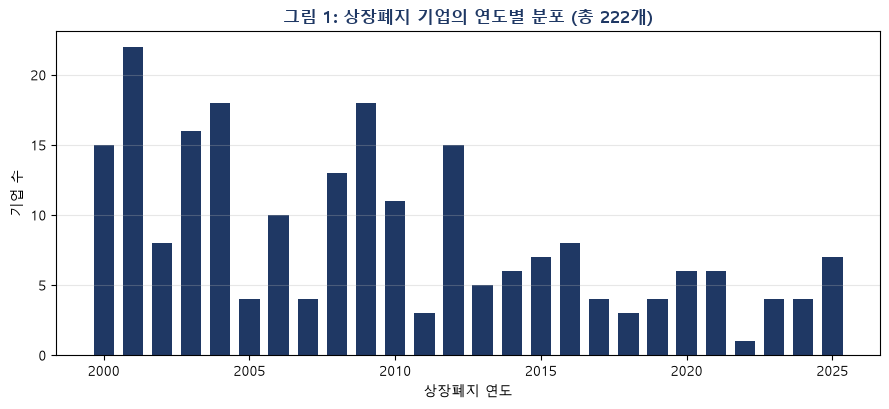

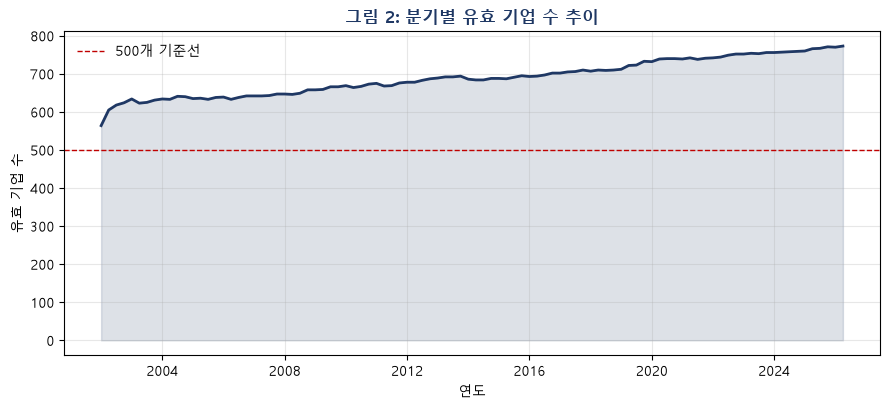

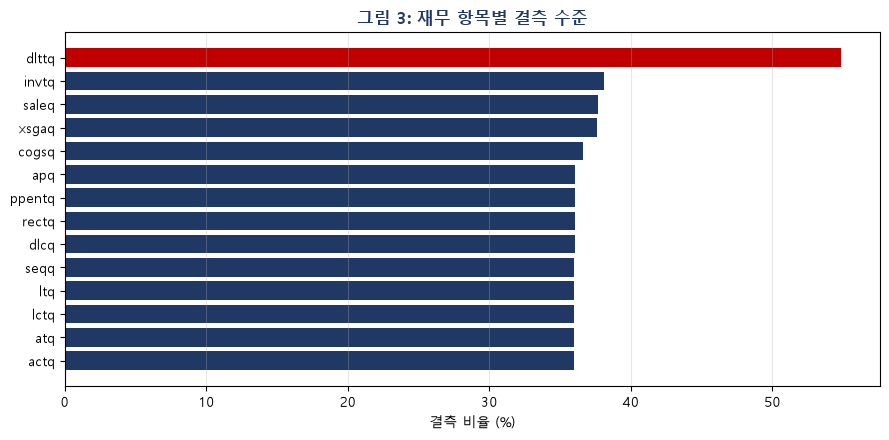

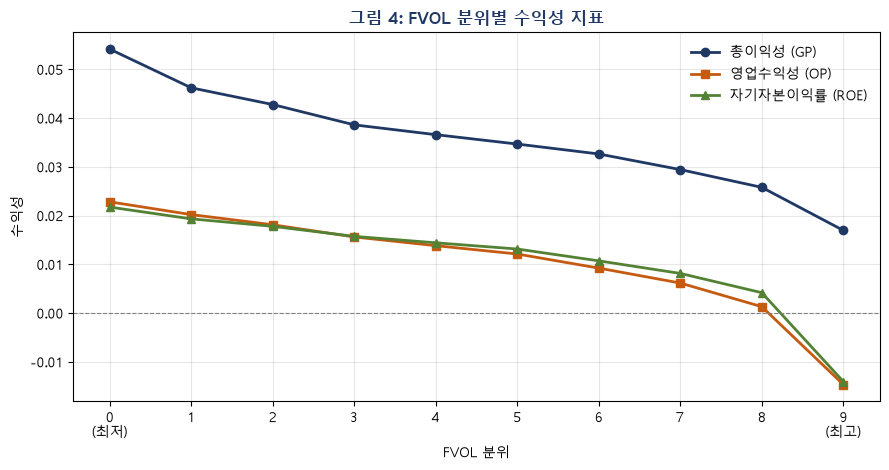

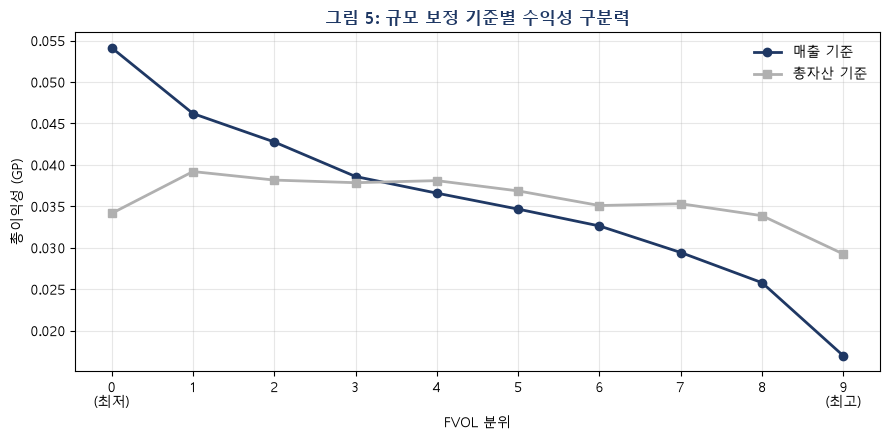

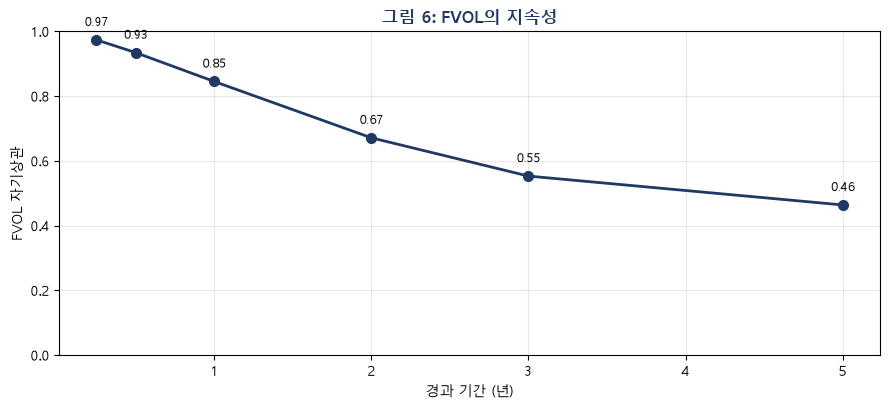

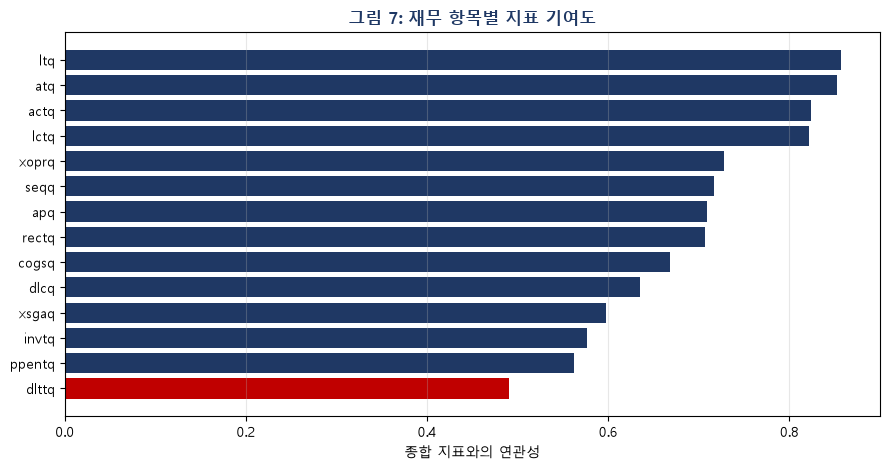

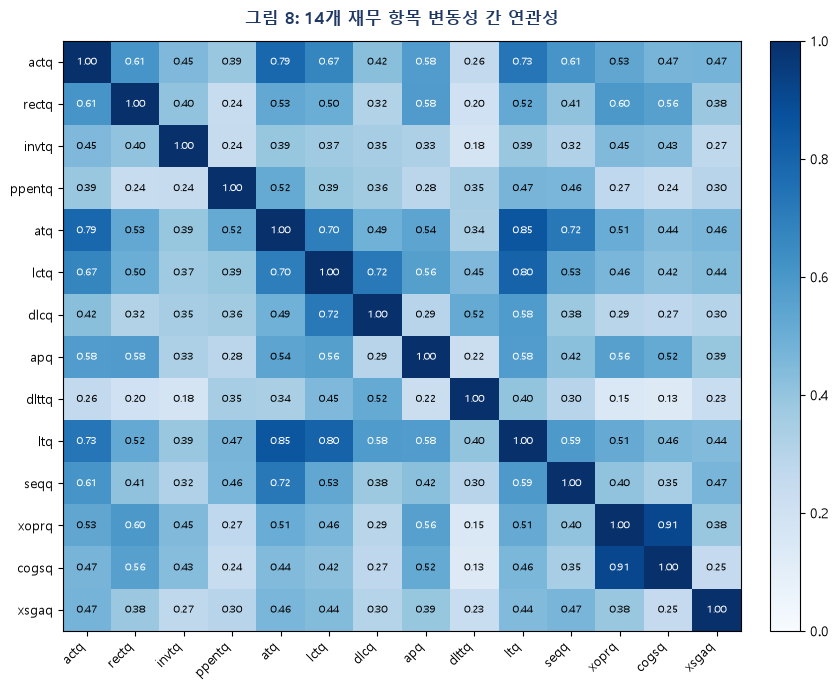

In [8]:
# 시각화

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
NAVY = '#1F3864'

financials = pd.read_parquet('financials.parquet')
fv, ind = compute_fvol(financials, deflator='saleq')
fv, col = finalize_fvol(fv, ind, suffix='')

d = fv.sort_values(['code','date']).copy()
g = d.groupby('code', sort=False)
d['atq_lag1'] = g['atq'].shift(1)
d['qbe'] = d['seqq'].fillna(0) + d['txditcq'].fillna(0) - d['pstkq'].fillna(0)
d['qbe_lag1'] = g['qbe'].shift(1)
d['GP'] = (d['saleq'] - d['cogsq']) / d['atq_lag1']
d['OP'] = (d['saleq'] - d['cogsq'] - d['xsgaq'] - d['xintq']) / d['qbe_lag1']
d['ROE'] = d['ibq'] / d['qbe_lag1']
for c in ['GP','OP','ROE']:
    d[c] = d[c].replace([np.inf,-np.inf], np.nan)

last_date = financials[financials['atq'].notna()].groupby('code')['date'].max()
cutoff = financials['date'].max()
delisted = last_date[last_date < cutoff - pd.Timedelta(days=200)]
dist = delisted.dt.year.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(dist.index, dist.values, color=NAVY, width=0.7)
ax.set_xlabel('상장폐지 연도'); ax.set_ylabel('기업 수')
ax.set_title('그림 1: 상장폐지 기업의 연도별 분포 (총 222개)', fontweight='bold', color=NAVY)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

gq = fv[fv['FVOL'].notna()].groupby('date').size()
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(gq.index, gq.values, color=NAVY, linewidth=2)
ax.fill_between(gq.index, gq.values, alpha=0.15, color=NAVY)
ax.axhline(500, color='#C00000', linestyle='--', linewidth=1, label='500개 기준선')
ax.set_xlabel('연도'); ax.set_ylabel('유효 기업 수')
ax.set_title('그림 2: 분기별 유효 기업 수 추이', fontweight='bold', color=NAVY)
ax.legend(frameon=False); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

ALL_ITEMS = ['actq','rectq','invtq','ppentq','atq','lctq','dlttq','dlcq','ltq',
             'seqq','cogsq','xsgaq','saleq','apq']
miss = {c: financials[c].isna().mean()*100 for c in ALL_ITEMS}
miss = pd.Series(miss).sort_values()
colors = ['#C00000' if c=='dlttq' else NAVY for c in miss.index]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(range(len(miss)), miss.values, color=colors)
ax.set_yticks(range(len(miss))); ax.set_yticklabels(miss.index)
ax.set_xlabel('결측 비율 (%)')
ax.set_title('그림 3: 재무 항목별 결측 수준', fontweight='bold', color=NAVY)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

v = d[d['FVOL'].notna()].copy()
v['dec'] = v.groupby('date')['FVOL'].transform(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop'))
series = {c: v.groupby(['date','dec'])[c].median().reset_index().groupby('dec')[c].mean() for c in ['GP','OP','ROE']}
fig, ax = plt.subplots(figsize=(9, 4.8))
labels = {'GP':'총이익성 (GP)', 'OP':'영업수익성 (OP)', 'ROE':'자기자본이익률 (ROE)'}
colors = {'GP':NAVY, 'OP':'#C55A11', 'ROE':'#548235'}
markers = {'GP':'o', 'OP':'s', 'ROE':'^'}
for c in ['GP','OP','ROE']:
    ax.plot(range(10), series[c].values, marker=markers[c], color=colors[c], label=labels[c], linewidth=2, markersize=6)
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xticks(range(10)); ax.set_xticklabels(['0\n(최저)','1','2','3','4','5','6','7','8','9\n(최고)'])
ax.set_xlabel('FVOL 분위'); ax.set_ylabel('수익성')
ax.set_title('그림 4: FVOL 분위별 수익성 지표', fontweight='bold', color=NAVY)
ax.legend(frameon=False); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

fv2, ind2 = compute_fvol(financials, deflator='atq')
fv2, _ = finalize_fvol(fv2, ind2, suffix='')
d2 = d.merge(fv2[['code','date','FVOL']].rename(columns={'FVOL':'FVOL_a'}), on=['code','date'])
v2 = d2[d2['FVOL_a'].notna()].copy()
v2['dec'] = v2.groupby('date')['FVOL_a'].transform(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop'))
gp_sale = series['GP']
gp_asset = v2.groupby(['date','dec'])['GP'].median().reset_index().groupby('dec')['GP'].mean()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(range(10), gp_sale.values, marker='o', color=NAVY, linewidth=2, label='매출 기준')
ax.plot(range(10), gp_asset.values, marker='s', color='#B0B0B0', linewidth=2, label='총자산 기준')
ax.set_xticks(range(10)); ax.set_xticklabels(['0\n(최저)','1','2','3','4','5','6','7','8','9\n(최고)'])
ax.set_xlabel('FVOL 분위'); ax.set_ylabel('총이익성 (GP)')
ax.set_title('그림 5: 규모 보정 기준별 수익성 구분력', fontweight='bold', color=NAVY)
ax.legend(frameon=False); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

dd = fv[['code','date','FVOL']].dropna().copy()
pq = pd.PeriodIndex(dd['date'], freq='Q')
dd['qidx'] = pq.year * 4 + (pq.quarter - 1)
lags = [1,2,4,8,12,20]; corrs = []
for lag in lags:
    a = dd.copy(); a['fut'] = a['qidx'] + lag
    m = a.merge(a[['code','qidx','FVOL']].rename(columns={'qidx':'fut','FVOL':'FVOL_f'}), on=['code','fut'], how='inner')
    corrs.append(m[['FVOL','FVOL_f']].corr().iloc[0,1])
fig, ax = plt.subplots(figsize=(9, 4.2))
years = [l/4 for l in lags]
ax.plot(years, corrs, marker='o', color=NAVY, linewidth=2, markersize=7)
for x,y in zip(years, corrs):
    ax.annotate(f'{y:.2f}', (x,y), textcoords='offset points', xytext=(0,10), ha='center', fontsize=9)
ax.set_xlabel('경과 기간 (년)'); ax.set_ylabel('FVOL 자기상관'); ax.set_ylim(0, 1)
ax.set_title('그림 6: FVOL의 지속성', fontweight='bold', color=NAVY)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

rcols = [f'rank_{c}' for c in FVOL_COLS]
valid = fv[fv['FVOL'].notna()]
contrib = {c: valid[[f'rank_{c}','FVOL']].corr().iloc[0,1] for c in FVOL_COLS}
contrib = pd.Series(contrib).sort_values()
colors = ['#C00000' if c=='dlttq' else NAVY for c in contrib.index]
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(range(len(contrib)), contrib.values, color=colors)
ax.set_yticks(range(len(contrib))); ax.set_yticklabels(contrib.index)
ax.set_xlabel('종합 지표와의 연관성')
ax.set_title('그림 7: 재무 항목별 지표 기여도', fontweight='bold', color=NAVY)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

rank_corr = valid[rcols].corr()
labels = list(FVOL_COLS)
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(rank_corr.values, cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(14)); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(14)); ax.set_yticklabels(labels, fontsize=9)
for i in range(14):
    for j in range(14):
        val = rank_corr.values[i,j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color='white' if val > 0.55 else 'black', fontsize=7)
ax.set_title('그림 8: 14개 재무 항목 변동성 간 연관성', fontweight='bold', color=NAVY, pad=12)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

In [9]:
# 7

PRICE_OUT = 'prices.parquet'
MARKET_OUT = 'market.parquet'

PRICE_SHEETS = {
    '27_return': 'ret',
    '28_mktcap': 'mktcap',
    '29_price': 'price',
    '30_dret': 'dret',
}

MARKET_SHEETS = {
    '31_kret': 'kret',
    '32_rf': 'rf',
}

def load_wide_sheet(path, sheet, var):
    raw = pd.read_excel(path, sheet_name=sheet, header=None)
    codes = raw.iloc[7, 1:].astype(str)
    mask = codes.str.startswith('A')
    codes = codes[mask]
    dates = pd.to_datetime(raw.iloc[14:, 0].tolist())
    vals = raw.iloc[14:, 1:].loc[:, mask.values].apply(pd.to_numeric, errors='coerce')
    vals.columns = codes.values
    vals.index = dates
    long = vals.stack().rename(var).reset_index()
    long.columns = ['date', 'code', var]
    return long[['code', 'date', var]]

def load_single_sheet(path, sheet, var):
    raw = pd.read_excel(path, sheet_name=sheet, header=None)
    dates = pd.to_datetime(raw.iloc[14:, 0].tolist())
    vals = pd.to_numeric(raw.iloc[14:, 1], errors='coerce')
    return pd.DataFrame({'date': dates, var: vals.values})

def build_prices(path=XLSX, out=PRICE_OUT):
    if Path(out).exists():
        df = pd.read_parquet(out)
        print(f'{out} loaded. shape {df.shape}  n_comp {df["code"].nunique()}')
        return df
    monthly = None
    for sheet, var in [('27_return', 'ret'), ('28_mktcap', 'mktcap'), ('29_price', 'price')]:
        long = load_wide_sheet(path, sheet, var)
        monthly = long if monthly is None else monthly.merge(long, on=['code', 'date'], how='outer')
    monthly = monthly.sort_values(['code', 'date']).reset_index(drop=True)
    monthly.to_parquet(out)
    print(f'{out} written. shape {monthly.shape}  n_comp {monthly["code"].nunique()}  n_date {monthly["date"].nunique()}')
    return monthly

def build_daily(path=XLSX, out='daily_returns.parquet'):
    if Path(out).exists():
        df = pd.read_parquet(out)
        print(f'{out} loaded. shape {df.shape}  n_comp {df["code"].nunique()}')
        return df
    daily = load_wide_sheet(path, '30_dret', 'dret')
    daily = daily.dropna(subset=['dret']).sort_values(['code', 'date']).reset_index(drop=True)
    daily.to_parquet(out)
    print(f'{out} written. shape {daily.shape}  n_comp {daily["code"].nunique()}  n_date {daily["date"].nunique()}')
    return daily

def build_market(path=XLSX, out=MARKET_OUT):
    if Path(out).exists():
        df = pd.read_parquet(out)
        print(f'{out} loaded. shape {df.shape}')
        return df
    kret = load_single_sheet(path, '31_kret', 'kret')
    rf = load_single_sheet(path, '32_rf', 'rf')
    market = kret.merge(rf, on='date', how='outer').sort_values('date').reset_index(drop=True)
    market.to_parquet(out)
    print(f'{out} written. shape {market.shape}  range {market["date"].min().date()}~{market["date"].max().date()}')
    return market

prices = build_prices()
daily_returns = build_daily()
market = build_market()

prices.parquet loaded. shape (356642, 5)  n_comp 1118
daily_returns.parquet loaded. shape (4384841, 3)  n_comp 964
market.parquet loaded. shape (6530, 3)


In [10]:
# 8

financials = pd.read_parquet('financials.parquet')
prices = pd.read_parquet('prices.parquet')

fv_s, ind = compute_fvol(financials, deflator='saleq')
fv_s, col_s = finalize_fvol(fv_s, ind, suffix='_sale')
fv_a, ind = compute_fvol(financials, deflator='atq')
fv_a, col_a = finalize_fvol(fv_a, ind, suffix='_asset')

sig = fv_s[['code', 'date', col_s]].merge(fv_a[['code', 'date', col_a]], on=['code', 'date'])
sig['form_qtr'] = pd.PeriodIndex(sig['date'], freq='Q') + 1

px = prices.copy()
px['ret'] = px['ret'] / 100.0
px['ym'] = pd.PeriodIndex(px['date'], freq='M')

form_px = px[px['ym'].dt.month.isin([3, 6, 9, 12])][['code', 'ym', 'price']].copy()
form_px['form_qtr'] = form_px['ym'].dt.asfreq('Q')

for col in [col_s, col_a]:
    f = sig[['code', 'form_qtr', col]].dropna().merge(
        form_px[['code', 'form_qtr', 'price']], on=['code', 'form_qtr'], how='inner')
    f = f[f['price'] >= 1000].copy()
    f['decile'] = np.ceil(f.groupby('form_qtr')[col].rank(pct=True) * 10).clip(1, 10).astype(int)
    f['form_ym'] = f['form_qtr'].dt.asfreq('M', how='end')

    holds = []
    for k in [1, 2, 3]:
        h = f[['code', 'form_ym', 'decile']].copy()
        h['hold_ym'] = h['form_ym'] + k
        holds.append(h)
    hold = pd.concat(holds, ignore_index=True)

    m = px[['code', 'ym', 'ret']].dropna().merge(
        hold, left_on=['code', 'ym'], right_on=['code', 'hold_ym'], how='inner')
    m = m.drop_duplicates(['code', 'form_ym', 'ym'])

    ew = m.groupby(['ym', 'decile'])['ret'].mean().reset_index(name='ewret')
    wide = ew.pivot(index='ym', columns='decile', values='ewret')
    lh = (wide[1] - wide[10]).dropna()
    t = lh.mean() / (lh.std() / np.sqrt(len(lh)))

    print(f'=== {col} ===')
    print(f'형성 관측치 {len(f)}  분기당 평균 종목 {f.groupby("form_qtr").size().mean():.0f}  '
          f'월수 {len(lh)}  기간 {lh.index.min()}~{lh.index.max()}')
    print(f'EW Low-High: {lh.mean()*100:.2f}%/월  t={t:.2f}')
    print(f'Low(1): {wide[1].mean()*100:.2f}%  High(10): {wide[10].mean()*100:.2f}%')
    print('decile별 평균 월수익률(%):')
    print((wide[list(range(1, 11))].mean() * 100).round(2).to_string())
    print()

=== FVOL_sale ===
형성 관측치 62590  분기당 평균 종목 639  월수 291  기간 2002-04~2026-06
EW Low-High: 0.82%/월  t=2.89
Low(1): 1.18%  High(10): 0.36%
decile별 평균 월수익률(%):
decile
1     1.18
2     1.35
3     1.33
4     1.23
5     1.18
6     1.34
7     1.36
8     1.01
9     0.83
10    0.36

=== FVOL_asset ===
형성 관측치 62619  분기당 평균 종목 639  월수 291  기간 2002-04~2026-06
EW Low-High: 0.50%/월  t=1.72
Low(1): 1.16%  High(10): 0.67%
decile별 평균 월수익률(%):
decile
1     1.16
2     1.17
3     1.25
4     1.38
5     1.16
6     1.28
7     1.23
8     1.00
9     0.85
10    0.67



In [11]:
# 9

financials = pd.read_parquet('financials.parquet')
prices = pd.read_parquet('prices.parquet')

fv, ind = compute_fvol(financials, deflator='saleq')
fv, col = finalize_fvol(fv, ind, suffix='')

sig = fv[['code', 'date', 'FVOL']].dropna().copy()
sig['form_qtr'] = pd.PeriodIndex(sig['date'], freq='Q') + 1

px = prices.copy()
px['ret'] = px['ret'] / 100.0
px['ym'] = pd.PeriodIndex(px['date'], freq='M')

form_px = px[px['ym'].dt.month.isin([3, 6, 9, 12])][['code', 'ym', 'price']].copy()
form_px['form_qtr'] = form_px['ym'].dt.asfreq('Q')

f = sig.merge(form_px[['code', 'form_qtr', 'price']], on=['code', 'form_qtr'], how='inner')
f = f[f['price'] >= 1000].copy()
f['decile'] = np.ceil(f.groupby('form_qtr')['FVOL'].rank(pct=True) * 10).clip(1, 10).astype(int)
f['form_ym'] = f['form_qtr'].dt.asfreq('M', how='end')

holds = []
for k in [1, 2, 3]:
    h = f[['code', 'form_ym', 'decile']].copy()
    h['hold_ym'] = h['form_ym'] + k
    holds.append(h)
hold = pd.concat(holds, ignore_index=True)

rp = px[['code', 'ym', 'ret', 'mktcap']].sort_values(['code', 'ym']).copy()
rp['w'] = rp.groupby('code')['mktcap'].shift(1)

m = rp.merge(hold, left_on=['code', 'ym'], right_on=['code', 'hold_ym'], how='inner')
m = m.dropna(subset=['ret', 'w'])
m = m.drop_duplicates(['code', 'form_ym', 'ym'])

vw = (m.groupby(['ym', 'decile'])
      .apply(lambda g: (g['ret'] * g['w']).sum() / g['w'].sum(), include_groups=False)
      .reset_index(name='vwret'))
wide = vw.pivot(index='ym', columns='decile', values='vwret')
lh = (wide[1] - wide[10]).dropna()
t = lh.mean() / (lh.std() / np.sqrt(len(lh)))

print(f'월수 {len(lh)}  기간 {lh.index.min()}~{lh.index.max()}')
print(f'VW Low-High: {lh.mean()*100:.2f}%/월  t={t:.2f}')
print(f'Low(1): {wide[1].mean()*100:.2f}%  High(10): {wide[10].mean()*100:.2f}%')
print('decile별 평균 월수익률(%):')
print((wide[list(range(1, 11))].mean() * 100).round(2).to_string())


월수 291  기간 2002-04~2026-06
VW Low-High: 0.20%/월  t=0.45
Low(1): 0.99%  High(10): 0.79%
decile별 평균 월수익률(%):
decile
1     0.99
2     1.60
3     1.25
4     0.89
5     0.81
6     1.10
7     1.12
8     0.46
9     0.83
10    0.79


In [12]:
# 10

financials = pd.read_parquet('financials.parquet')
prices = pd.read_parquet('prices.parquet')

fv, ind = compute_fvol(financials, deflator='saleq')
fv, col = finalize_fvol(fv, ind, suffix='')

sig = fv[['code', 'date', 'FVOL']].dropna().copy()
sig['form_qtr'] = pd.PeriodIndex(sig['date'], freq='Q') + 1

px = prices.copy()
px['ret'] = px['ret'] / 100.0
px['ym'] = pd.PeriodIndex(px['date'], freq='M')

form_px = px[px['ym'].dt.month.isin([3, 6, 9, 12])][['code', 'ym', 'price']].copy()
form_px['form_qtr'] = form_px['ym'].dt.asfreq('Q')

f = sig.merge(form_px[['code', 'form_qtr', 'price']], on=['code', 'form_qtr'], how='inner')
f = f[f['price'] >= 1000].copy()
f['decile'] = np.ceil(f.groupby('form_qtr')['FVOL'].rank(pct=True) * 10).clip(1, 10).astype(int)
f['form_ym'] = f['form_qtr'].dt.asfreq('M', how='end')

holds = []
for k in range(1, 25):
    h = f[['code', 'form_ym', 'decile']].copy()
    h['hold_ym'] = h['form_ym'] + k
    h['qtr'] = (k - 1) // 3 + 1
    holds.append(h)
hold = pd.concat(holds, ignore_index=True)

m = px[['code', 'ym', 'ret']].dropna().merge(
    hold, left_on=['code', 'ym'], right_on=['code', 'hold_ym'], how='inner')
m = m.drop_duplicates(['code', 'form_ym', 'ym', 'qtr'])

ew = m.groupby(['qtr', 'ym', 'decile'])['ret'].mean().reset_index(name='r')

print(f'{"Q":5}{"L-H%":>7}{"t":>7}{"Low%":>7}{"High%":>7}{"월수":>6}')
parts = []
for qtr in range(1, 9):
    w = ew[ew['qtr'] == qtr].pivot(index='ym', columns='decile', values='r')
    lh = (w[1] - w[10]).dropna()
    parts.append(lh.rename(f'q{qtr}'))
    t = lh.mean() / (lh.std() / np.sqrt(len(lh)))
    print(f'Q{qtr:<4}{lh.mean()*100:7.2f}{t:7.2f}{w[1].mean()*100:7.2f}{w[10].mean()*100:7.2f}{len(lh):6d}')

jt = pd.concat(parts, axis=1)
lh_jt = jt.mean(axis=1).dropna()
t = lh_jt.mean() / (lh_jt.std() / np.sqrt(len(lh_jt)))
print(f'{"JT8":5}{lh_jt.mean()*100:7.2f}{t:7.2f}{"":7}{"":7}{len(lh_jt):6d}')

Q       L-H%      t   Low%  High%    월수
Q1      0.82   2.89   1.18   0.36   291
Q2      0.71   2.70   1.24   0.52   288
Q3      0.66   2.49   1.25   0.59   285
Q4      0.72   2.67   1.27   0.54   282
Q5      0.59   2.15   1.24   0.65   279
Q6      0.68   2.50   1.25   0.57   276
Q7      0.55   2.01   1.25   0.70   273
Q8      0.39   1.41   1.16   0.77   270
JT8     0.71   2.62                 291


In [13]:
# 11

fv, ind = compute_fvol(financials, deflator='saleq')
fv, col = finalize_fvol(fv, ind, suffix='')

px = prices.copy()
px['ret'] = px['ret'] / 100.0
px['ym'] = pd.PeriodIndex(px['date'], freq='M')

form_px = px[px['ym'].dt.month.isin([3, 6, 9, 12])][['code', 'ym', 'price']].copy()
form_px['form_qtr'] = form_px['ym'].dt.asfreq('Q')

ret_m = px[['code', 'ym', 'ret']].dropna()

def lowhigh(sig, valcol):
    s = sig.dropna(subset=[valcol]).copy()
    s['form_qtr'] = pd.PeriodIndex(s['date'], freq='Q') + 1
    f = s.merge(form_px[['code', 'form_qtr', 'price']], on=['code', 'form_qtr'], how='inner')
    f = f[f['price'] >= 1000].copy()
    f['decile'] = np.ceil(f.groupby('form_qtr')[valcol].rank(pct=True) * 10).clip(1, 10).astype(int)
    f['form_ym'] = f['form_qtr'].dt.asfreq('M', how='end')
    holds = []
    for k in [1, 2, 3]:
        h = f[['code', 'form_ym', 'decile']].copy()
        h['hold_ym'] = h['form_ym'] + k
        holds.append(h)
    hold = pd.concat(holds, ignore_index=True)
    m = ret_m.merge(hold, left_on=['code', 'ym'], right_on=['code', 'hold_ym'], how='inner')
    m = m.drop_duplicates(['code', 'form_ym', 'ym'])
    ew = m.groupby(['ym', 'decile'])['ret'].mean().reset_index(name='r')
    w = ew.pivot(index='ym', columns='decile', values='r')
    lh = (w[1] - w[10]).dropna()
    t = lh.mean() / (lh.std() / np.sqrt(len(lh)))
    nfirm = f.groupby('form_qtr').size().mean()
    return lh.mean() * 100, t, w[1].mean() * 100, w[10].mean() * 100, nfirm

print(f'{"item":10}{"L-H%":>7}{"t":>7}{"Low%":>7}{"High%":>7}{"종목/분기":>9}')
for c in FVOL_COLS:
    r, t, lo, hi, n = lowhigh(fv[['code', 'date', f'fvol_{c}']], f'fvol_{c}')
    print(f'{c:10}{r:7.2f}{t:7.2f}{lo:7.2f}{hi:7.2f}{n:9.0f}')

r, t, lo, hi, n = lowhigh(fv[['code', 'date', 'FVOL']], 'FVOL')
print(f'{"FVOL":10}{r:7.2f}{t:7.2f}{lo:7.2f}{hi:7.2f}{n:9.0f}')

item         L-H%      t   Low%  High%    종목/분기
actq         0.82   3.31   1.30   0.48      639
rectq        0.70   2.66   1.18   0.48      639
invtq        0.19   0.77   0.99   0.80      617
ppentq       0.44   2.28   1.21   0.77      639
atq          0.89   3.75   1.32   0.43      639
lctq         0.93   3.90   1.25   0.31      639
dlcq         0.66   2.90   1.04   0.38      639
apq          0.57   2.29   1.06   0.48      639
dlttq        0.51   1.96   1.18   0.68      424
ltq          0.81   3.13   1.18   0.37      639
seqq         0.75   2.84   1.24   0.49      639
xoprq        0.65   2.54   1.17   0.52      634
cogsq        0.54   2.12   1.06   0.51      638
xsgaq        0.76   2.75   1.21   0.45      634
FVOL         0.82   2.89   1.18   0.36      639


In [14]:
# 12

fv, ind = compute_fvol(financials, deflator='saleq')
fv, col = finalize_fvol(fv, ind, suffix='')

MIN_FRAC = 10 / 14

px = prices.copy()
px['ret'] = px['ret'] / 100.0
px['ym'] = pd.PeriodIndex(px['date'], freq='M')
form_px = px[px['ym'].dt.month.isin([3, 6, 9, 12])][['code', 'ym', 'price']].copy()
form_px['form_qtr'] = form_px['ym'].dt.asfreq('Q')

rcols = [f'rank_{c}' for c in FVOL_COLS]
sig = fv[['code', 'date'] + rcols].copy()
sig['form_qtr'] = pd.PeriodIndex(sig['date'], freq='Q') + 1

f_base = sig.merge(form_px[['code', 'form_qtr', 'price']], on=['code', 'form_qtr'], how='inner')
f_base = f_base[f_base['price'] >= 1000].reset_index(drop=True)
f_base['form_ym'] = f_base['form_qtr'].dt.asfreq('M', how='end')
f_base['fid'] = np.arange(len(f_base))

R = f_base[rcols].to_numpy()
qtr_codes, _ = pd.factorize(f_base['form_qtr'])
n_qtr = qtr_codes.max() + 1

holds = []
for k in [1, 2, 3]:
    h = f_base[['fid', 'code', 'form_ym']].copy()
    h['hold_ym'] = h['form_ym'] + k
    holds.append(h)
hold = pd.concat(holds, ignore_index=True)

ret_m = px[['code', 'ym', 'ret']].dropna()
panel = ret_m.merge(hold, left_on=['code', 'ym'], right_on=['code', 'hold_ym'], how='inner')
panel = panel.drop_duplicates(['fid', 'ym'])
fid_p = panel['fid'].to_numpy()
ym_codes, ym_uniq = pd.factorize(panel['ym'])
ym_p = ym_codes
ret_p = panel['ret'].to_numpy()
n_ym = len(ym_uniq)

qtr_sorter = np.argsort(qtr_codes, kind='stable')
qtr_sorted = qtr_codes[qtr_sorter]
qtr_starts = np.searchsorted(qtr_sorted, np.arange(n_qtr))
qtr_ends = np.searchsorted(qtr_sorted, np.arange(n_qtr), side='right')

def eval_combo(idx):
    sub = R[:, idx]
    nv = np.sum(~np.isnan(sub), axis=1)
    with np.errstate(invalid='ignore'):
        score = np.nanmean(sub, axis=1)
    score[nv < int(np.ceil(len(idx) * MIN_FRAC))] = np.nan

    dec = np.full(len(score), np.nan)
    for q in range(n_qtr):
        rows = qtr_sorter[qtr_starts[q]:qtr_ends[q]]
        s = score[rows]
        ok = ~np.isnan(s)
        n = ok.sum()
        if n == 0:
            continue
        r = np.empty(n)
        r[np.argsort(s[ok], kind='stable')] = np.arange(1, n + 1)
        d = np.ceil(r / n * 10)
        np.clip(d, 1, 10, out=d)
        tmp = np.full(len(rows), np.nan)
        tmp[ok] = d
        dec[rows] = tmp

    n_form = (~np.isnan(dec)) .sum() / n_qtr

    dec_p = dec[fid_p]
    ok = ~np.isnan(dec_p)
    key = ym_p[ok] * 10 + (dec_p[ok].astype(int) - 1)
    sums = np.bincount(key, weights=ret_p[ok], minlength=n_ym * 10).reshape(n_ym, 10)
    cnts = np.bincount(key, minlength=n_ym * 10).reshape(n_ym, 10)
    with np.errstate(invalid='ignore'):
        mean = np.where(cnts > 0, sums / cnts, np.nan)
    lh = mean[:, 0] - mean[:, 9]
    valid = ~np.isnan(lh)
    lh = lh[valid]
    if len(lh) < 24:
        return np.nan, np.nan, len(lh), np.nan, np.nan, n_form
    lo = np.nanmean(mean[valid, 0]) * 100
    hi = np.nanmean(mean[valid, 9]) * 100
    return (lh.mean() * 100,
            lh.mean() / (lh.std(ddof=1) / np.sqrt(len(lh))),
            len(lh), lo, hi, n_form)

tasks = []
for k in range(1, 15):
    for combo in combinations(range(14), k):
        tasks.append(combo)
print(f'조합 수: {len(tasks)}')

inc = np.zeros((len(tasks), 14), dtype=bool)
t0 = time.time()
rows = []
for i, combo in enumerate(tasks):
    inc[i, list(combo)] = True
    lh, t, nmo, lo, hi, nf = eval_combo(list(combo))
    rows.append({'k': len(combo),
                 'items': '|'.join(FVOL_COLS[j] for j in combo),
                 'excluded': '|'.join(FVOL_COLS[j] for j in range(14) if j not in combo) or '(none)',
                 'lh': lh, 't': t, 'n_month': nmo,
                 'low': lo, 'high': hi, 'n_form': nf})

res = pd.DataFrame(rows)
res.to_parquet('combo_full_all.parquet')
np.save('combo_inc_mask.npy', inc)

print('\n=== 정합성: full14 ===')
print(res[res['k'] == 14][['lh', 't', 'low', 'high', 'n_form']].round(2).to_string(index=False))
print('(기존 #8: LH 0.82 t 2.89 Low 1.18 High 0.36 / 형성 639)')

print('\n=== k별 분포 ===')
print(res.groupby('k').agg(lh_m=('lh', 'mean'), lh_sd=('lh', 'std'),
                           t_m=('t', 'mean'), t_min=('t', 'min'), t_max=('t', 'max'),
                           nform_m=('n_form', 'mean')).round(2).to_string())

print('\n=== k별 최고 조합 (t 기준) ===')
best = res.loc[res.groupby('k')['t'].idxmax()]
print(best[['k', 'excluded', 'lh', 't', 'low', 'high', 'n_form']].round(2).to_string(index=False))

print('\n=== k별 최악 조합 (t 기준) ===')
worst = res.loc[res.groupby('k')['t'].idxmin()]
print(worst[['k', 'items', 'lh', 't', 'low', 'high', 'n_form']].round(2).to_string(index=False))

print('\n=== t 상위 15 / 하위 15 (전체) ===')
print(res.nlargest(15, 't')[['k', 'excluded', 'lh', 't', 'low', 'high']].round(2).to_string(index=False))
print()
print(res.nsmallest(15, 't')[['k', 'items', 'lh', 't', 'low', 'high']].round(2).to_string(index=False))

print('\n=== lh 상위 10 / 하위 10 (전체) ===')
print(res.nlargest(10, 'lh')[['k', 'excluded', 'lh', 't']].round(2).to_string(index=False))
print()
print(res.nsmallest(10, 'lh')[['k', 'items', 'lh', 't']].round(2).to_string(index=False))

print('\n=== 항목별 한계기여 (전체: 포함 평균 t − 제외 평균 t) ===')
tv = res['t'].to_numpy()
ok_t = ~np.isnan(tv)
contrib = {}
for j, c in enumerate(FVOL_COLS):
    m_in = tv[inc[:, j] & ok_t].mean()
    m_out = tv[~inc[:, j] & ok_t].mean()
    contrib[c] = m_in - m_out
    print(f'  {c:8s}: 포함 {m_in:.2f}  제외 {m_out:.2f}  차이 {m_in - m_out:+.2f}')

print('\n=== 항목별 한계기여 (k별, 포함−제외 t 차이) ===')
kv = res['k'].to_numpy()
hdr = '  ' + 'item'.ljust(8) + ''.join(f'k={k:<6}' for k in range(4, 14))
print(hdr)
for j, c in enumerate(FVOL_COLS):
    line = f'  {c:8s}'
    for k in range(4, 14):
        mk = (kv == k) & ok_t
        a = tv[mk & inc[:, j]]
        b = tv[mk & ~inc[:, j]]
        line += f'{a.mean() - b.mean():+.2f}  ' if len(a) and len(b) else '   .   '
    print(line)

print('\n=== 쌍 상호작용 (동시 제외 시너지, k 무조건부) ===')
pairs = []
for a in range(14):
    for b in range(a + 1, 14):
        m11 = tv[inc[:, a] & inc[:, b] & ok_t].mean()
        m01 = tv[~inc[:, a] & inc[:, b] & ok_t].mean()
        m10 = tv[inc[:, a] & ~inc[:, b] & ok_t].mean()
        m00 = tv[~inc[:, a] & ~inc[:, b] & ok_t].mean()
        syn = m00 - m01 - m10 + m11
        pairs.append({'pair': f'{FVOL_COLS[a]}+{FVOL_COLS[b]}',
                      'both_excl_t': m00, 'synergy': syn})
pr = pd.DataFrame(pairs)
print('동시 제외 시 평균 t 상위 8쌍:')
print(pr.nlargest(8, 'both_excl_t').round(3).to_string(index=False))
print('\n시너지(비가법성) 절대값 상위 8쌍:')
pr['abs_syn'] = pr['synergy'].abs()
print(pr.nlargest(8, 'abs_syn')[['pair', 'both_excl_t', 'synergy']].round(3).to_string(index=False))

print('\n=== Low/High 분해: t 상위 15 조합의 개선 원천 ===')
b14 = res[res['k'] == 14].iloc[0]
top = res.nlargest(15, 't').copy()
top['dLow'] = top['low'] - b14['low']
top['dHigh'] = top['high'] - b14['high']
print(f'(full14 기준 Low {b14["low"]:.2f} High {b14["high"]:.2f})')
print(top[['k', 'excluded', 'lh', 't', 'dLow', 'dHigh']].round(2).to_string(index=False))

조합 수: 16383


NameError: name 'time' is not defined

In [ ]:
# 13

financials = pd.read_parquet('financials.parquet')
prices = pd.read_parquet('prices.parquet')

fv, ind = compute_fvol(financials, deflator='saleq')
fv, col = finalize_fvol(fv, ind, suffix='')

sig = fv[['code', 'date', 'FVOL']].dropna().copy()
sig['form_qtr'] = pd.PeriodIndex(sig['date'], freq='Q') + 1

px = prices.copy()
px['ym'] = pd.PeriodIndex(px['date'], freq='M')
form_px = px[px['ym'].dt.month.isin([3, 6, 9, 12])][['code', 'ym', 'price', 'mktcap']].copy()
form_px['form_qtr'] = form_px['ym'].dt.asfreq('Q')

f = sig.merge(form_px[['code', 'form_qtr', 'price', 'mktcap']], on=['code', 'form_qtr'], how='inner')
f = f[f['price'] >= 1000].dropna(subset=['mktcap']).copy()
f['decile'] = np.ceil(f.groupby('form_qtr')['FVOL'].rank(pct=True) * 10).clip(1, 10).astype(int)

print('=== 1. decile별 시총 점유율 (분기별 점유율의 평균, %) — 논문 Figure 2 대응 ===')
qsum = f.groupby('form_qtr')['mktcap'].transform('sum')
f['share'] = f['mktcap'] / qsum
share = f.groupby(['form_qtr', 'decile'])['share'].sum().reset_index()
avg_share = share.groupby('decile')['share'].mean() * 100
print(avg_share.round(1).to_string())
print(f'(논문 미국: d1 16.3% → d10 5.2%)')

print('\n=== 2. decile별 시총 분포 (중앙값, 조원) ===')
med = f.groupby('decile')['mktcap'].median() / 1e12
print(med.round(3).to_string())

print('\n=== 3. decile별 최대 종목 집중도 ===')
top1 = (f.sort_values('mktcap', ascending=False)
        .groupby(['form_qtr', 'decile']).head(1)
        .groupby(['form_qtr', 'decile'])['mktcap'].sum())
dsum = f.groupby(['form_qtr', 'decile'])['mktcap'].sum()
conc = (top1 / dsum).reset_index(name='c').groupby('decile')['c'].mean() * 100
print('decile 내 1위 종목의 시총 비중 평균(%):')
print(conc.round(1).to_string())

print('\n=== 4. d1·d10의 대표 얼굴 (최근 형성 분기) ===')
last_q = f['form_qtr'].max()
recent = f[f['form_qtr'] == last_q]
for dc in [1, 10]:
    top = recent[recent['decile'] == dc].nlargest(5, 'mktcap')
    print(f'\ndecile {dc} 시총 상위 5 ({last_q}):')
    print((top[['code', 'mktcap']].assign(조원=lambda x: (x['mktcap']/1e12).round(2))
           [['code', '조원']]).to_string(index=False))

print('\n=== 5. 시총 5분위 × FVOL: 대형주에서 신호가 있는가 ===')
f['size_q'] = f.groupby('form_qtr')['mktcap'].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates='drop')) + 1
f['fq'] = f.groupby(['form_qtr', 'size_q'])['FVOL'].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates='drop')) + 1
f = f.dropna(subset=['fq'])
f['form_ym'] = f['form_qtr'].dt.asfreq('M', how='end')

px['ret'] = px['ret'] / 100.0
ret_m = px[['code', 'ym', 'ret']].dropna()
holds = []
for k in [1, 2, 3]:
    h = f[['code', 'form_ym', 'size_q', 'fq']].copy()
    h['hold_ym'] = h['form_ym'] + k
    holds.append(h)
hold = pd.concat(holds, ignore_index=True)
m = ret_m.merge(hold, left_on=['code', 'ym'], right_on=['code', 'hold_ym'], how='inner')
m = m.drop_duplicates(['code', 'form_ym', 'ym'])
cell = m.groupby(['size_q', 'ym', 'fq'])['ret'].mean().reset_index(name='r')

print('사이즈 분위(1=소형, 5=대형)별 FVOL Low-High (EW, %/월):')
print(f'{"size_q":>7}{"L-H%":>7}{"t":>7}{"월수":>6}')
for sq in range(1, 6):
    w = cell[cell['size_q'] == sq].pivot(index='ym', columns='fq', values='r')
    if 1 not in w or 5 not in w:
        continue
    lh = (w[1] - w[5]).dropna()
    t = lh.mean() / (lh.std(ddof=1) / np.sqrt(len(lh)))
    print(f'{sq:>7}{lh.mean()*100:7.2f}{t:7.2f}{len(lh):6d}')

=== 1. decile별 시총 점유율 (분기별 점유율의 평균, %) — 논문 Figure 2 대응 ===
decile
1     23.2
2     14.9
3     11.4
4      9.5
5      8.3
6      7.8
7      8.2
8      6.7
9      5.5
10     4.4
(논문 미국: d1 16.3% → d10 5.2%)

=== 2. decile별 시총 분포 (중앙값, 조원) ===
decile
1     0.279
2     0.221
3     0.200
4     0.185
5     0.179
6     0.171
7     0.158
8     0.139
9     0.125
10    0.103

=== 3. decile별 최대 종목 집중도 ===
decile 내 1위 종목의 시총 비중 평균(%):
decile
1     38.8
2     34.1
3     31.4
4     30.6
5     29.2
6     29.7
7     34.4
8     34.8
9     30.9
10    36.6

=== 4. d1·d10의 대표 얼굴 (최근 형성 분기) ===

decile 1 시총 상위 5 (2026Q2):
   code    조원
A000270 53.88
A012330 45.37
A066570 33.07
A005490 25.12
A015760 23.75

decile 10 시총 상위 5 (2026Q2):
   code    조원
A207940 64.39
A012450 51.31
A068270 40.30
A006400 39.25
A003670 15.62

=== 5. 시총 5분위 × FVOL: 대형주에서 신호가 있는가 ===
사이즈 분위(1=소형, 5=대형)별 FVOL Low-High (EW, %/월):
 size_q   L-H%      t    월수
      1   0.85   1.95   291
      2   1.68   5.62   291
      3   0.57   1.80  

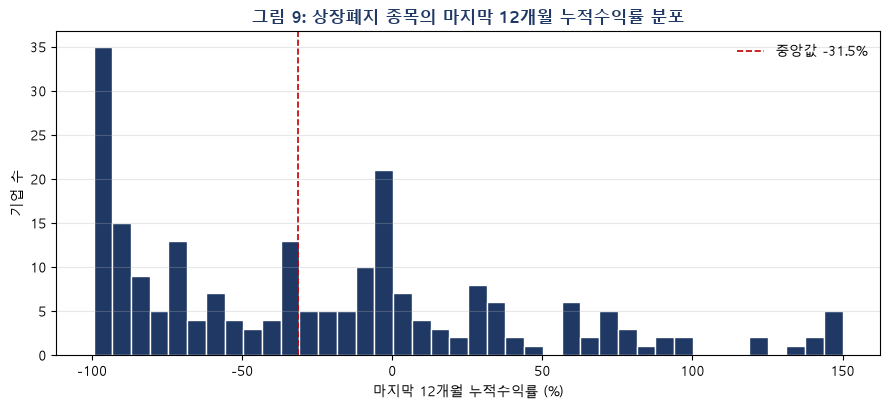

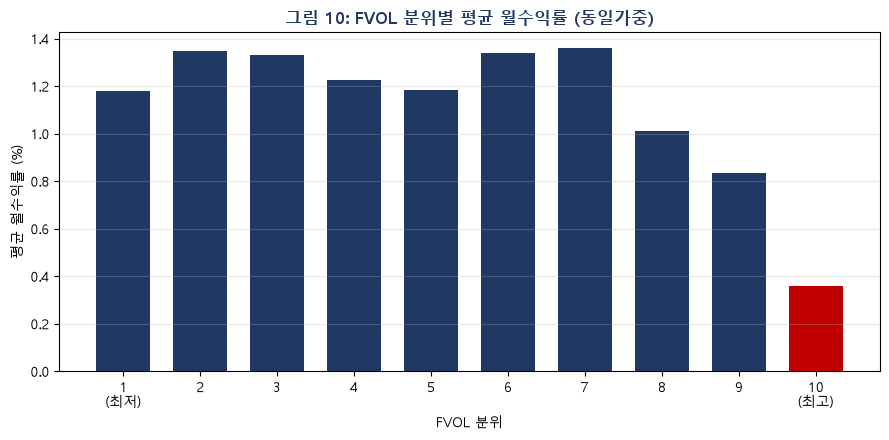

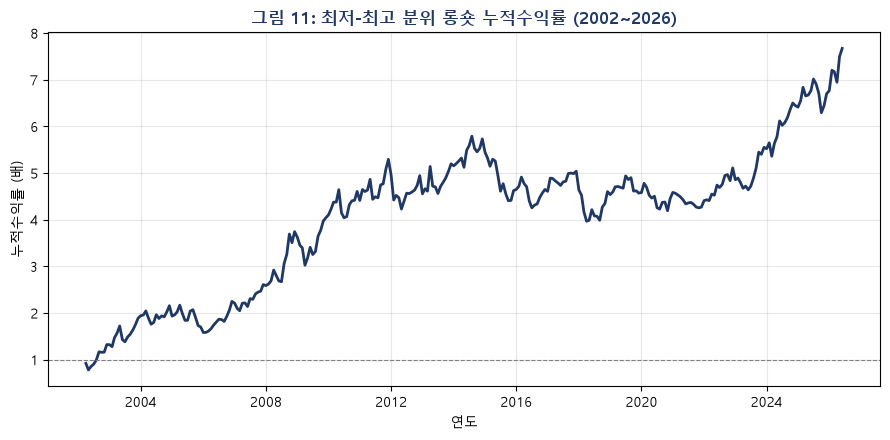

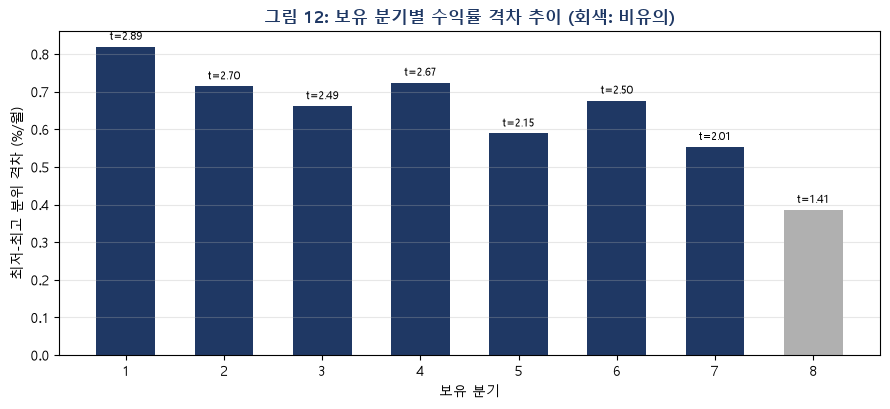

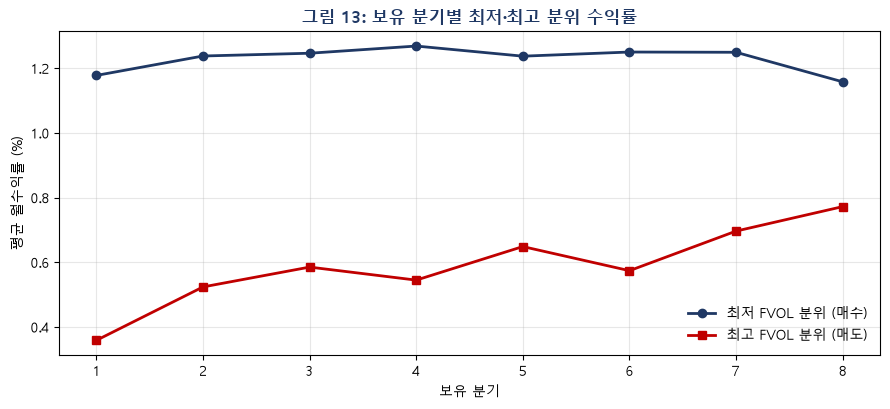

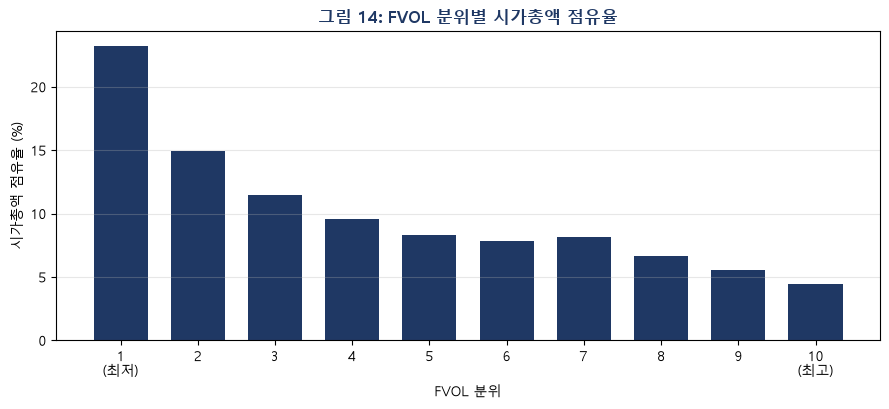

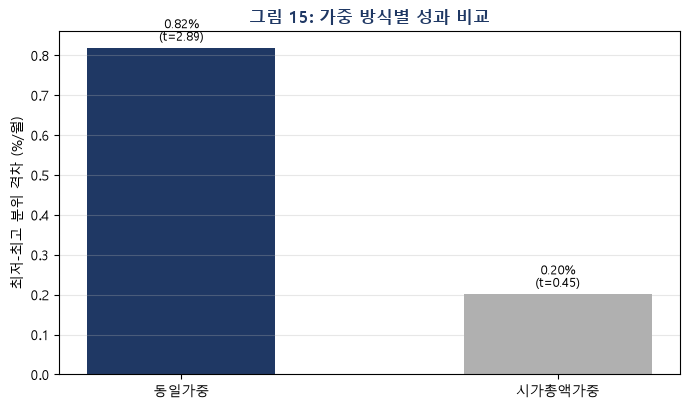

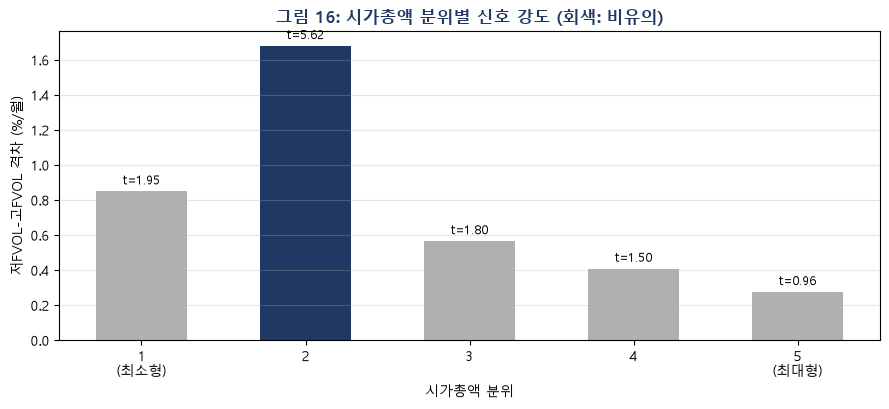

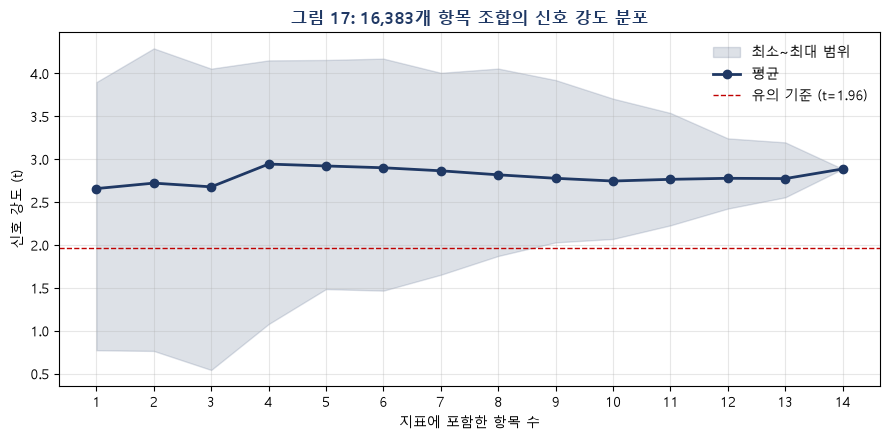

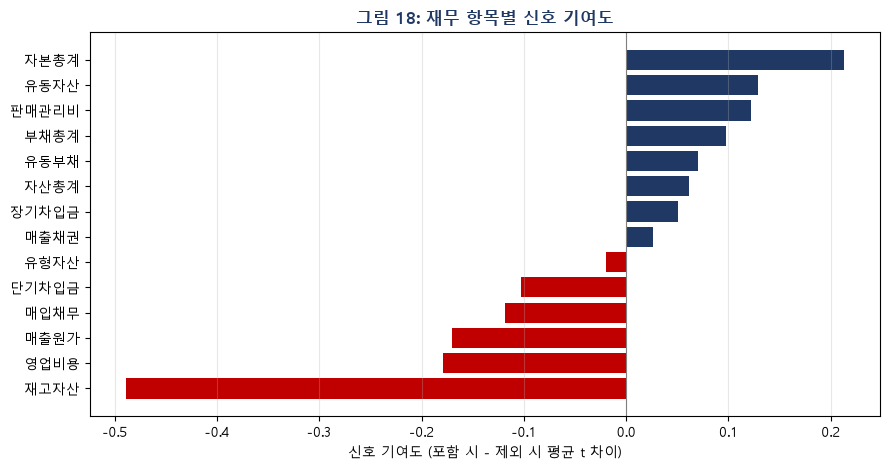

In [ ]:
# 시각화

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
NAVY = '#1F3864'
RED = '#C00000'
GRAY = '#B0B0B0'

financials = pd.read_parquet('financials.parquet')
prices = pd.read_parquet('prices.parquet')

fv, ind = compute_fvol(financials, deflator='saleq')
fv, col = finalize_fvol(fv, ind, suffix='')

px = prices.copy()
px['ret'] = px['ret'] / 100.0
px['ym'] = pd.PeriodIndex(px['date'], freq='M')
ret_m = px[['code', 'ym', 'ret']].dropna()

sig = fv[['code', 'date', 'FVOL']].dropna().copy()
sig['form_qtr'] = pd.PeriodIndex(sig['date'], freq='Q') + 1
form_px = px[px['ym'].dt.month.isin([3, 6, 9, 12])][['code', 'ym', 'price', 'mktcap']].copy()
form_px['form_qtr'] = form_px['ym'].dt.asfreq('Q')

f = sig.merge(form_px[['code', 'form_qtr', 'price', 'mktcap']], on=['code', 'form_qtr'], how='inner')
f = f[f['price'] >= 1000].copy()
f['decile'] = np.ceil(f.groupby('form_qtr')['FVOL'].rank(pct=True) * 10).clip(1, 10).astype(int)
f['form_ym'] = f['form_qtr'].dt.asfreq('M', how='end')

fin_last = financials[financials['atq'].notna()].groupby('code')['date'].max()
cutoff = financials['date'].max()
delisted = fin_last[fin_last < cutoff - pd.Timedelta(days=200)].index
pd_del = px[px['code'].isin(delisted) & px['ret'].notna()].sort_values(['code', 'date'])
cum12 = pd_del.groupby('code').tail(12).groupby('code')['ret'].apply(lambda s: (1 + s).prod() - 1) * 100
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.hist(cum12.clip(-100, 150), bins=40, color=NAVY, edgecolor='white')
ax.axvline(cum12.median(), color=RED, linestyle='--', linewidth=1.2, label=f'중앙값 {cum12.median():.1f}%')
ax.set_xlabel('마지막 12개월 누적수익률 (%)'); ax.set_ylabel('기업 수')
ax.set_title('그림 9: 상장폐지 종목의 마지막 12개월 누적수익률 분포', fontweight='bold', color=NAVY)
ax.legend(frameon=False); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

holds = []
for k in [1, 2, 3]:
    h = f[['code', 'form_ym', 'decile']].copy()
    h['hold_ym'] = h['form_ym'] + k
    holds.append(h)
hold = pd.concat(holds, ignore_index=True)
m = ret_m.merge(hold, left_on=['code', 'ym'], right_on=['code', 'hold_ym'], how='inner')
m = m.drop_duplicates(['code', 'form_ym', 'ym'])
ew = m.groupby(['ym', 'decile'])['ret'].mean().reset_index(name='r')
wide = ew.pivot(index='ym', columns='decile', values='r')
dec_mean = wide[list(range(1, 11))].mean() * 100
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = [NAVY] * 9 + [RED]
ax.bar(range(1, 11), dec_mean.values, color=colors, width=0.7)
ax.set_xticks(range(1, 11)); ax.set_xticklabels(['1\n(최저)'] + [str(i) for i in range(2, 10)] + ['10\n(최고)'])
ax.set_xlabel('FVOL 분위'); ax.set_ylabel('평균 월수익률 (%)')
ax.set_title('그림 10: FVOL 분위별 평균 월수익률 (동일가중)', fontweight='bold', color=NAVY)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

lh_m = (wide[1] - wide[10]).dropna()
cum = (1 + lh_m).cumprod()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(cum.index.to_timestamp(), cum.values, color=NAVY, linewidth=2)
ax.axhline(1, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('연도'); ax.set_ylabel('누적수익률 (배)')
ax.set_title('그림 11: 최저-최고 분위 롱숏 누적수익률 (2002~2026)', fontweight='bold', color=NAVY)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

holds = []
for k in range(1, 25):
    h = f[['code', 'form_ym', 'decile']].copy()
    h['hold_ym'] = h['form_ym'] + k
    h['qtr'] = (k - 1) // 3 + 1
    holds.append(h)
hold = pd.concat(holds, ignore_index=True)
m = ret_m.merge(hold, left_on=['code', 'ym'], right_on=['code', 'hold_ym'], how='inner')
m = m.drop_duplicates(['code', 'form_ym', 'ym', 'qtr'])
ewq = m.groupby(['qtr', 'ym', 'decile'])['ret'].mean().reset_index(name='r')
lh_q, t_q, lo_q, hi_q = [], [], [], []
for qtr in range(1, 9):
    w = ewq[ewq['qtr'] == qtr].pivot(index='ym', columns='decile', values='r')
    lh = (w[1] - w[10]).dropna()
    lh_q.append(lh.mean() * 100)
    t_q.append(lh.mean() / (lh.std(ddof=1) / np.sqrt(len(lh))))
    lo_q.append(w[1].mean() * 100)
    hi_q.append(w[10].mean() * 100)

fig, ax = plt.subplots(figsize=(9, 4.2))
cols4 = [NAVY if t >= 1.96 else GRAY for t in t_q]
ax.bar(range(1, 9), lh_q, color=cols4, width=0.6)
for x, (y, t) in enumerate(zip(lh_q, t_q), start=1):
    ax.annotate(f't={t:.2f}', (x, y), textcoords='offset points', xytext=(0, 5), ha='center', fontsize=8)
ax.set_xlabel('보유 분기'); ax.set_ylabel('최저-최고 분위 격차 (%/월)')
ax.set_title('그림 12: 보유 분기별 수익률 격차 추이 (회색: 비유의)', fontweight='bold', color=NAVY)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(range(1, 9), lo_q, marker='o', color=NAVY, linewidth=2, label='최저 FVOL 분위 (매수)')
ax.plot(range(1, 9), hi_q, marker='s', color=RED, linewidth=2, label='최고 FVOL 분위 (매도)')
ax.set_xlabel('보유 분기'); ax.set_ylabel('평균 월수익률 (%)')
ax.set_title('그림 13: 보유 분기별 최저·최고 분위 수익률', fontweight='bold', color=NAVY)
ax.legend(frameon=False); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

fm = f.dropna(subset=['mktcap']).copy()
qsum = fm.groupby('form_qtr')['mktcap'].transform('sum')
fm['share'] = fm['mktcap'] / qsum
share = fm.groupby(['form_qtr', 'decile'])['share'].sum().reset_index()
avg_share = share.groupby('decile')['share'].mean() * 100
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(range(1, 11), avg_share.values, color=NAVY, width=0.7)
ax.set_xticks(range(1, 11)); ax.set_xticklabels(['1\n(최저)'] + [str(i) for i in range(2, 10)] + ['10\n(최고)'])
ax.set_xlabel('FVOL 분위'); ax.set_ylabel('시가총액 점유율 (%)')
ax.set_title('그림 14: FVOL 분위별 시가총액 점유율', fontweight='bold', color=NAVY)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

rp = px[['code', 'ym', 'ret', 'mktcap']].sort_values(['code', 'ym']).copy()
rp['w'] = rp.groupby('code')['mktcap'].shift(1)
holds = []
for k in [1, 2, 3]:
    h = f[['code', 'form_ym', 'decile']].copy()
    h['hold_ym'] = h['form_ym'] + k
    holds.append(h)
hold = pd.concat(holds, ignore_index=True)
mv = rp.merge(hold, left_on=['code', 'ym'], right_on=['code', 'hold_ym'], how='inner')
mv = mv.dropna(subset=['ret', 'w']).drop_duplicates(['code', 'form_ym', 'ym'])
vw = (mv.groupby(['ym', 'decile'])
      .apply(lambda g: (g['ret'] * g['w']).sum() / g['w'].sum(), include_groups=False)
      .reset_index(name='r'))
wv = vw.pivot(index='ym', columns='decile', values='r')
lh_vw = (wv[1] - wv[10]).dropna()
ew_val, ew_t = lh_m.mean() * 100, lh_m.mean() / (lh_m.std(ddof=1) / np.sqrt(len(lh_m)))
vw_val, vw_t = lh_vw.mean() * 100, lh_vw.mean() / (lh_vw.std(ddof=1) / np.sqrt(len(lh_vw)))
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar([0, 1], [ew_val, vw_val], color=[NAVY, GRAY], width=0.5)
for x, (y, t) in enumerate(zip([ew_val, vw_val], [ew_t, vw_t])):
    ax.annotate(f'{y:.2f}%\n(t={t:.2f})', (x, y), textcoords='offset points', xytext=(0, 5), ha='center', fontsize=9)
ax.set_xticks([0, 1]); ax.set_xticklabels(['동일가중', '시가총액가중'])
ax.set_ylabel('최저-최고 분위 격차 (%/월)')
ax.set_title('그림 15: 가중 방식별 성과 비교', fontweight='bold', color=NAVY)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

fs = f.dropna(subset=['mktcap']).copy()
fs['size_q'] = fs.groupby('form_qtr')['mktcap'].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates='drop')) + 1
fs['fq'] = fs.groupby(['form_qtr', 'size_q'])['FVOL'].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates='drop')) + 1
fs = fs.dropna(subset=['fq'])
holds = []
for k in [1, 2, 3]:
    h = fs[['code', 'form_ym', 'size_q', 'fq']].copy()
    h['hold_ym'] = h['form_ym'] + k
    holds.append(h)
hold = pd.concat(holds, ignore_index=True)
ms = ret_m.merge(hold, left_on=['code', 'ym'], right_on=['code', 'hold_ym'], how='inner')
ms = ms.drop_duplicates(['code', 'form_ym', 'ym'])
cell = ms.groupby(['size_q', 'ym', 'fq'])['ret'].mean().reset_index(name='r')
sz_lh, sz_t = [], []
for sq in range(1, 6):
    w = cell[cell['size_q'] == sq].pivot(index='ym', columns='fq', values='r')
    lh = (w[1] - w[5]).dropna()
    sz_lh.append(lh.mean() * 100)
    sz_t.append(lh.mean() / (lh.std(ddof=1) / np.sqrt(len(lh))))
fig, ax = plt.subplots(figsize=(9, 4.2))
cols8 = [NAVY if t >= 1.96 else GRAY for t in sz_t]
ax.bar(range(1, 6), sz_lh, color=cols8, width=0.55)
for x, (y, t) in enumerate(zip(sz_lh, sz_t), start=1):
    ax.annotate(f't={t:.2f}', (x, y), textcoords='offset points', xytext=(0, 5), ha='center', fontsize=9)
ax.set_xticks(range(1, 6))
ax.set_xticklabels(['1\n(최소형)', '2', '3', '4', '5\n(최대형)'])
ax.set_xlabel('시가총액 분위'); ax.set_ylabel('저FVOL-고FVOL 격차 (%/월)')
ax.set_title('그림 16: 시가총액 분위별 신호 강도 (회색: 비유의)', fontweight='bold', color=NAVY)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

res = pd.read_parquet('combo_full_all.parquet')
gb = res.groupby('k')['t'].agg(['mean', 'min', 'max'])
fig, ax = plt.subplots(figsize=(9, 4.5))
ks = gb.index.values
ax.fill_between(ks, gb['min'], gb['max'], color=NAVY, alpha=0.15, label='최소~최대 범위')
ax.plot(ks, gb['mean'], marker='o', color=NAVY, linewidth=2, label='평균')
ax.axhline(1.96, color=RED, linestyle='--', linewidth=1, label='유의 기준 (t=1.96)')
ax.set_xticks(ks)
ax.set_xlabel('지표에 포함한 항목 수'); ax.set_ylabel('신호 강도 (t)')
ax.set_title('그림 17: 16,383개 항목 조합의 신호 강도 분포', fontweight='bold', color=NAVY)
ax.legend(frameon=False); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

inc = np.load('combo_inc_mask.npy')
tv = res['t'].to_numpy()
ok_t = ~np.isnan(tv)
contrib = {}
for j, c in enumerate(FVOL_COLS):
    contrib[c] = tv[inc[:, j] & ok_t].mean() - tv[~inc[:, j] & ok_t].mean()
contrib = pd.Series(contrib).sort_values()
KOR = {'actq': '유동자산', 'rectq': '매출채권', 'invtq': '재고자산', 'ppentq': '유형자산',
       'atq': '자산총계', 'lctq': '유동부채', 'dlcq': '단기차입금', 'apq': '매입채무',
       'dlttq': '장기차입금', 'ltq': '부채총계', 'seqq': '자본총계',
       'xoprq': '영업비용', 'cogsq': '매출원가', 'xsgaq': '판매관리비'}
labels = [KOR[c] for c in contrib.index]
colors10 = [RED if v < 0 else NAVY for v in contrib.values]
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(range(len(contrib)), contrib.values, color=colors10)
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_yticks(range(len(contrib))); ax.set_yticklabels(labels)
ax.set_xlabel('신호 기여도 (포함 시 - 제외 시 평균 t 차이)')
ax.set_title('그림 18: 재무 항목별 신호 기여도', fontweight='bold', color=NAVY)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()